# NIRSpec/G395M NRS1: fit and publication plots

This compact HAT-P-18 b workflow writes a complete YAML file, fits the white-light curve and an R=20 NRS1 spectrum, then renders both products with the shared publication style.

## Before running

The saved output below was produced on a GPU. The source uses `host_device: "cpu"` so it can be rerun without one, although CPU execution is slower. Set `KOALA_EXAMPLE_DATA_ROOT` to the directory containing your extracted FITS file. A fresh result directory is required so existing products are never replaced.

The R=20 grid and reduced tutorial draw counts keep this an executable example rather than a publication inference. Increase the sampling counts and restore the desired science grid for an analysis.

In [1]:
from copy import deepcopy
import os
from pathlib import Path
import subprocess
import sys
import time

from IPython.display import Image, display
import pandas as pd
import yaml

REPO_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "fit_jwst.py").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the Koala checkout.")
DATA_ROOT = Path(os.environ.get(
    "KOALA_EXAMPLE_DATA_ROOT", str(REPO_ROOT / "examples" / "data")
))
DEFAULT_RESULT_ROOT = REPO_ROOT / "example_outputs" / "nirspec_g395m"
RESULT_ROOT = Path(os.environ.get(
    "KOALA_NOTEBOOK_RESULT_ROOT", DEFAULT_RESULT_ROOT
))
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from tools.notebook_demo_runtime import apply_bounded_demo_runtime
print(f"Repository: {REPO_ROOT}")
print(f"Input root: {DATA_ROOT}")
print(f"Result root: {RESULT_ROOT}")


Repository: <repository checkout>
Input root: examples/data
Result root: example_outputs/nirspec_g395m


## Write the YAML configuration

The dictionary below is the notebook's complete fitting config. The source value of `host_device` remains `cpu`; the queued execution used an environment override without changing this cell.

In [2]:
example = {'planet': {'name': 'HAT-P-18', 'period': 5.50802941, 'duration': 0.10999998, 't0': 60795.39, 'b': 0.148, 'rprs': 0.1356}, 'stellar': {'teff': 4710, 'logg': 4.17, 'feh': 0.06, 'ld_model': 'stagger', 'ld_data_path': str(REPO_ROOT / 'exotic_ld_data')}, 'instrument': 'NIRSPEC/G395M', 'nrs': 1, 'fits_file': 'HAT-P-18_nrs1_box_spectra_fullres_G395M.fits', 'resolution': {'high': 20, 'low': 20}, 'mask': {'start': 60795.15, 'end': 60795.26}, 'random_seed': 751}
CONFIG = {
    "planet": example["planet"],
    "stellar": example["stellar"],
    "instrument": example["instrument"],
    "path": str(RESULT_ROOT),
    "input_dir": str(DATA_ROOT),
    "fits_file": example["fits_file"],
    "output_dir": "fit_output",
    "resolution": example["resolution"],
    "flags": {
        "transit_engine": "jaxoplanet",
        "vmap_chunk": 32,
        "detrending_type": "linear",
        "ld_profile": "power2",
        "ld_prior": "fixed",
        "need_lowres": False,
        "spectro_sampler": "independent_nuts",
        "random_seed": example["random_seed"],
        "mask_start": example["mask"]["start"],
        "mask_end": example["mask"]["end"],
    },
    "outlier_clip": {
        "whitelight_sigma": 5,
        "spectroscopic_sigma": 5,
    },
    "host_device": "cpu",
}
if "order" in example:
    CONFIG["order"] = example["order"]
if "nrs" in example:
    CONFIG["nrs"] = example["nrs"]

runtime_config = deepcopy(CONFIG)
apply_bounded_demo_runtime(runtime_config)
runtime_config["host_device"] = os.environ.get(
    "KOALA_NOTEBOOK_DEVICE", CONFIG["host_device"]
)
if RESULT_ROOT.exists() and any(RESULT_ROOT.iterdir()):
    allowed = {"source.ipynb", "source_v2.ipynb", "executed.ipynb"}
    unexpected = {path.name for path in RESULT_ROOT.iterdir()} - allowed
    if unexpected:
        raise FileExistsError(
            f"Refusing to reuse non-empty result directory: {RESULT_ROOT}"
        )
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
config_path = RESULT_ROOT / "run_config.yaml"
if config_path.exists():
    raise FileExistsError(f"Refusing to overwrite {config_path}")
config_path.write_text(
    yaml.safe_dump(runtime_config, sort_keys=False), encoding="utf-8"
)
print(f"Wrote {config_path}")
print(f"Runtime device: {runtime_config['host_device']}")
print("Saved notebook source device:", CONFIG["host_device"])


Wrote example_outputs/nirspec_g395m/run_config.yaml
Runtime device: gpu
Saved notebook source device: cpu


## Run the fit

The fitter writes its normal numbered diagnostics, white-light table, checkpoints, and R=20 spectrum. Only the tail of the log is printed here; the complete log is kept beside the YAML.

In [3]:
run_env = os.environ.copy()
run_env["JAX_ENABLE_X64"] = "1"
if runtime_config["host_device"] == "gpu":
    run_env["JAX_PLATFORMS"] = "gpu"
else:
    run_env["JAX_PLATFORMS"] = "cpu"
    run_env["OMP_NUM_THREADS"] = "8"
    run_env["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false"

started = time.perf_counter()
completed = subprocess.run(
    [sys.executable, "fit_jwst.py", "-c", str(config_path)],
    cwd=REPO_ROOT,
    env=run_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)
elapsed_seconds = time.perf_counter() - started
log_path = RESULT_ROOT / "fit.log"
log_path.write_text(completed.stdout, encoding="utf-8")
print("\n".join(completed.stdout.splitlines()[-35:]))
print(f"\nFit wall time: {elapsed_seconds:.1f} s")
print(f"Full log: {log_path}")
completed.check_returncode()


log_jitter    -10.796047  0.402822    -11.511394  ...   65.130592   24.171383    NaN
rors_0          0.137045  0.000056      0.136951  ...  407.477119  275.760354    NaN
t0_0        60795.386928  0.000012  60795.386907  ...  368.658525  230.300648    NaN
v              -0.000799  0.000127     -0.001050  ...  280.203958  155.109743    NaN

[16 rows x 9 columns]
Beta: 1.1748
Measured Beta: 1.175
MC Mean Beta:  0.921
MC Std Dev:    0.137
Significance:  1.85 sigma
Saved white-light time series to example_outputs/nirspec_g395m/fit_output/HAT-P-18_NIRSPEC_G395M_nrs1_whitelight_timeseries.csv
Saved white-light fixed-geometry handoff to example_outputs/nirspec_g395m/fit_output/HAT-P-18_NIRSPEC_G395M_nrs1_whitelight_geometry_handoff.json.
Using white-light geometry handoff (posterior_median, fingerprint=86eceecced88) for spectroscopic fitting.

--- Running High-Resolution Analysis (Binned to R20) ---
Jaxoplanet transit window (high-res): 387/686 active cadences.
Building jaxoplanet vectorized m

## Locate the numerical products

Plots are regenerated below from the CSV outputs rather than from hidden notebook state.

In [4]:
fit_dir = RESULT_ROOT / "fit_output"
white_path = fit_dir / "HAT-P-18_NIRSPEC_G395M_nrs1_whitelight_timeseries.csv"
spectrum_path = fit_dir / "HAT-P-18_NIRSPEC_G395M_nrs1_R20.csv"
if not white_path.is_file() or not spectrum_path.is_file():
    raise FileNotFoundError(
        f"Expected products were not written: {white_path}, {spectrum_path}"
    )
white = pd.read_csv(white_path)
spectrum = pd.read_csv(spectrum_path)
print(f"White-light cadences: {len(white)}")
print(f"Spectral channels: {len(spectrum)}")
display(spectrum.head())


White-light cadences: 686
Spectral channels: 11


,wavelength,wavelength_err,depth00,depth_err00,depth_ppm00,depth_err_ppm00,sampler_used
0,2.900835,0.081125,0.018877,0.000050,18877.225853,49.830077,independent_nuts
1,3.063086,0.083394,0.018730,0.000033,18729.863739,32.934786,independent_nuts
2,3.234411,0.088058,0.018765,0.000030,18764.843385,30.093109,independent_nuts
3,3.415319,0.092984,0.018699,0.000030,18698.541481,30.242463,independent_nuts
4,3.606346,0.098185,0.018679,0.000033,18679.093754,33.159164,independent_nuts


## White-light curve

Open circles mark retained data, grey points mark clipped outliers, and the lower panel uses symmetric residual ticks.

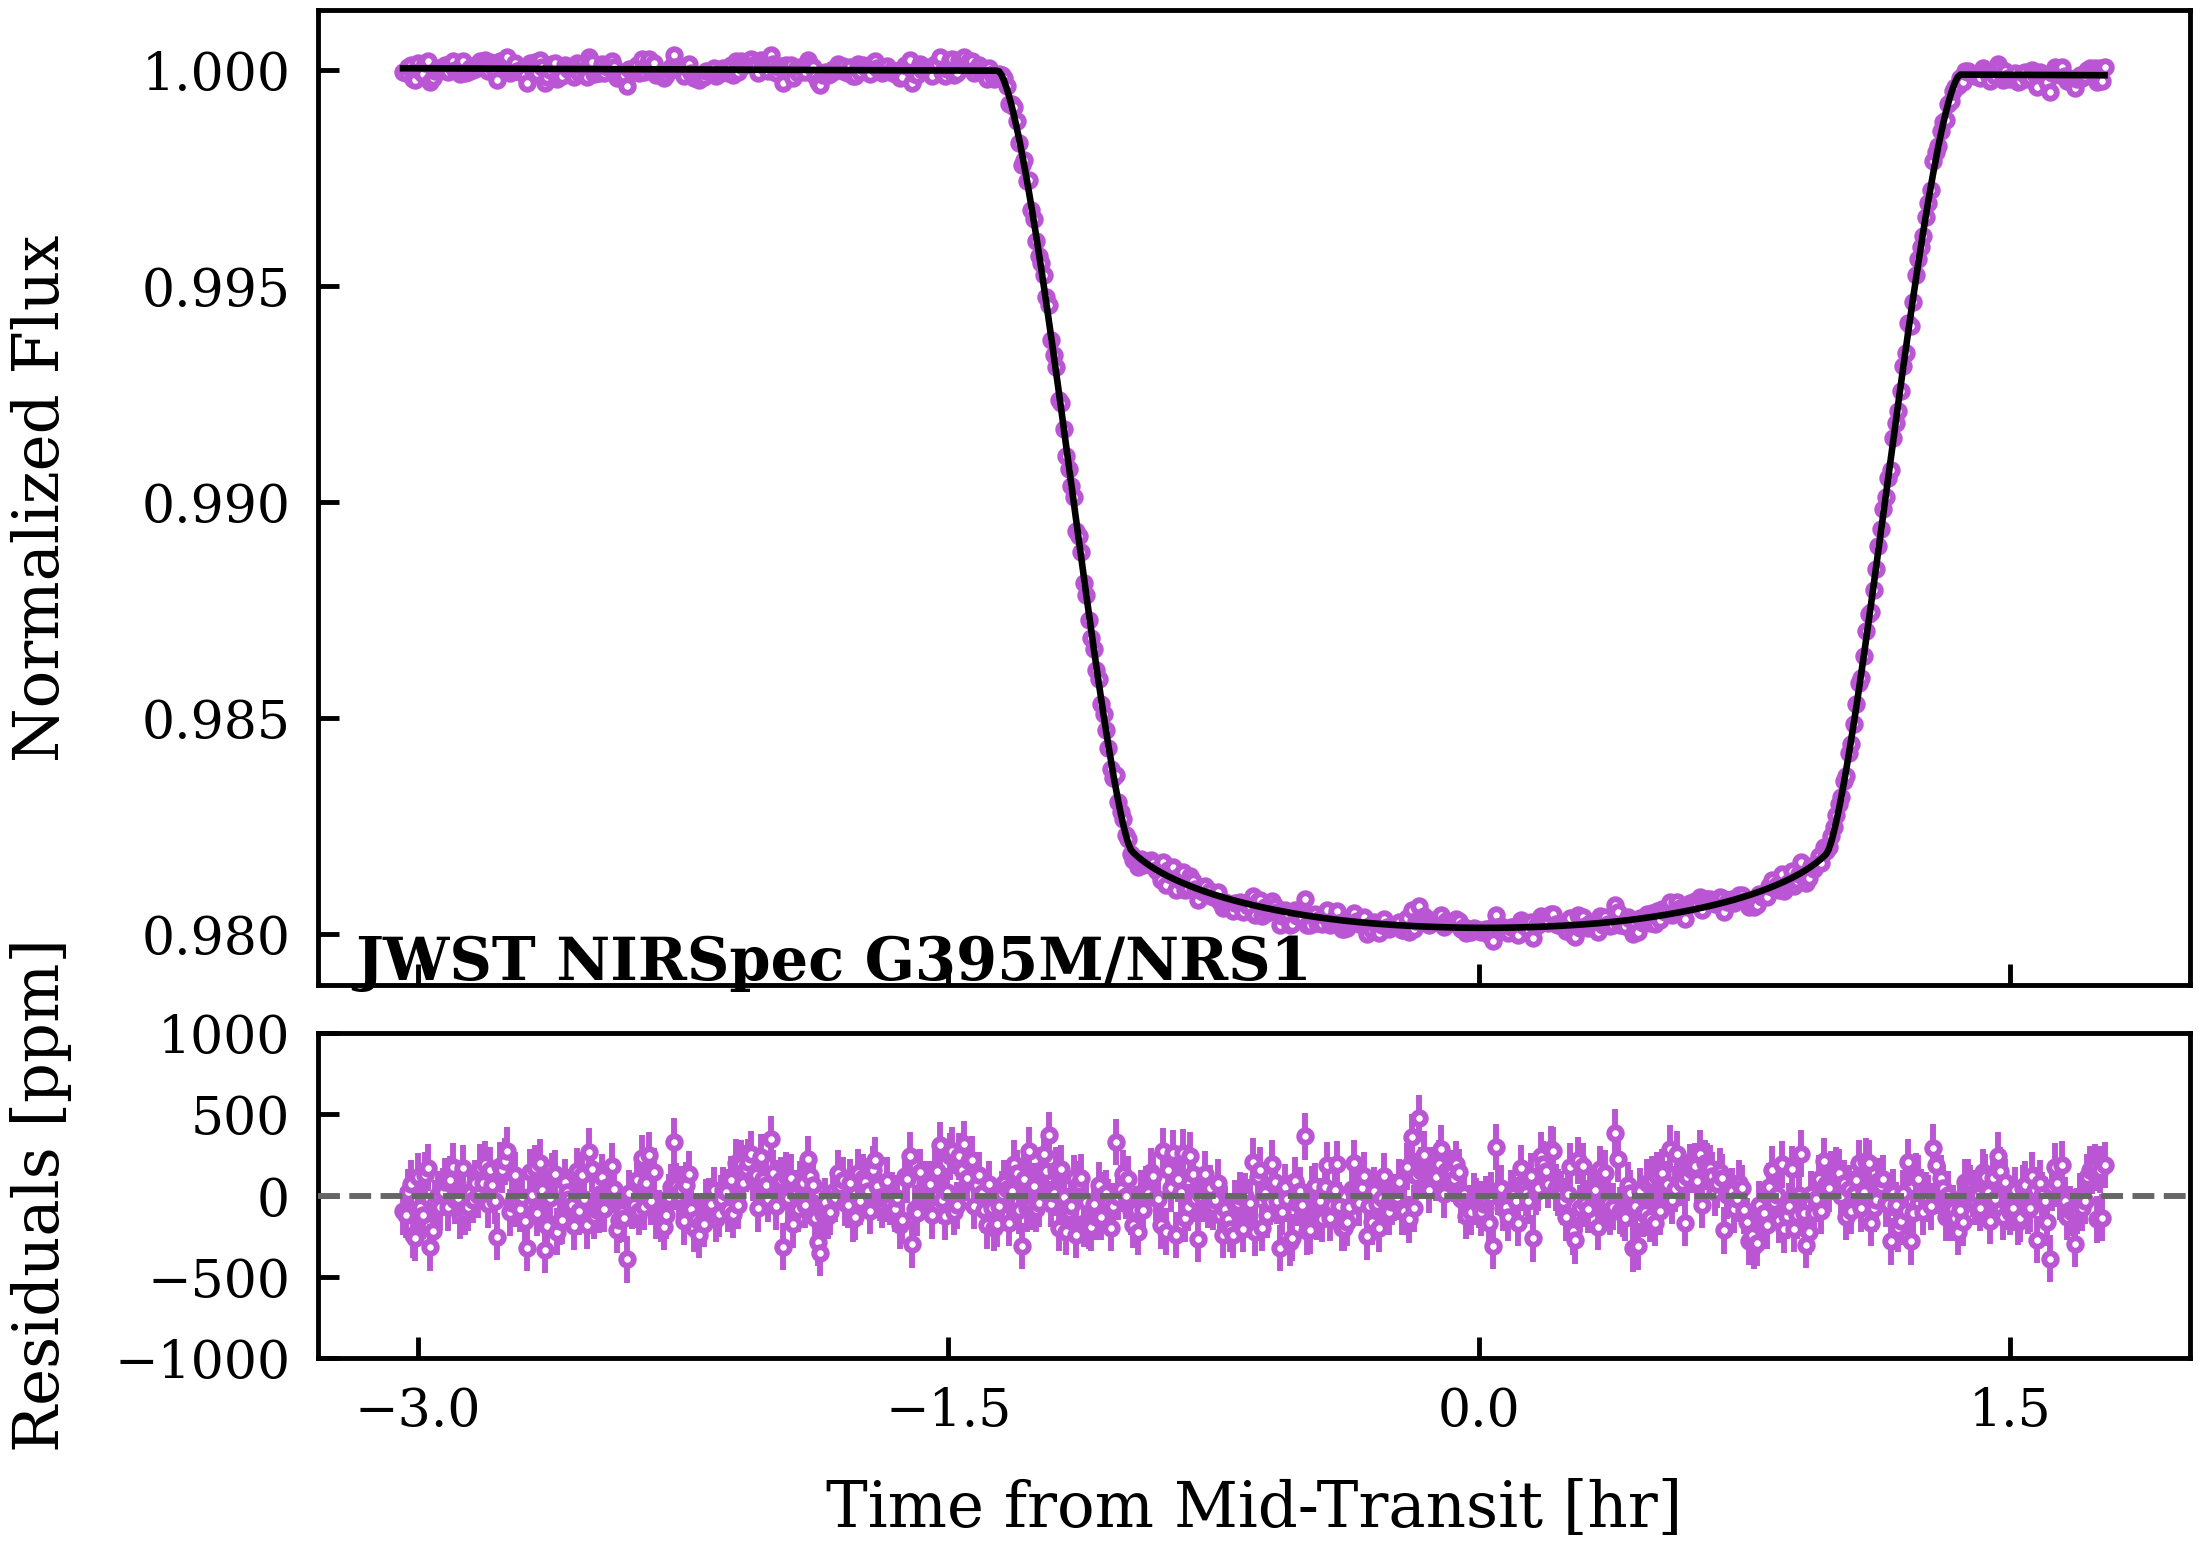

In [5]:
from plotting import plot_whitelight_curve

white_figure = RESULT_ROOT / "notebook_whitelight_publication.png"
if white_figure.exists():
    raise FileExistsError(f"Refusing to overwrite {white_figure}")
plot_whitelight_curve(
    white["time_bjd"],
    white["flux"],
    white["flux_err"],
    white["bestfit_model"],
    white_figure,
    instrument_label="HAT-P-18_NIRSPEC_G395M_nrs1",
    t0_reference=(
        white["time_bjd"].iloc[0]
        - white["time_from_t0_hr"].iloc[0] / 24.0
    ),
    outlier_mask=white["is_outlier"].astype(bool),
)
display(Image(filename=str(white_figure)))


## Transmission spectrum and precision

The lower panel makes the wavelength dependence of the measured uncertainty visible without adding extra figure annotations.

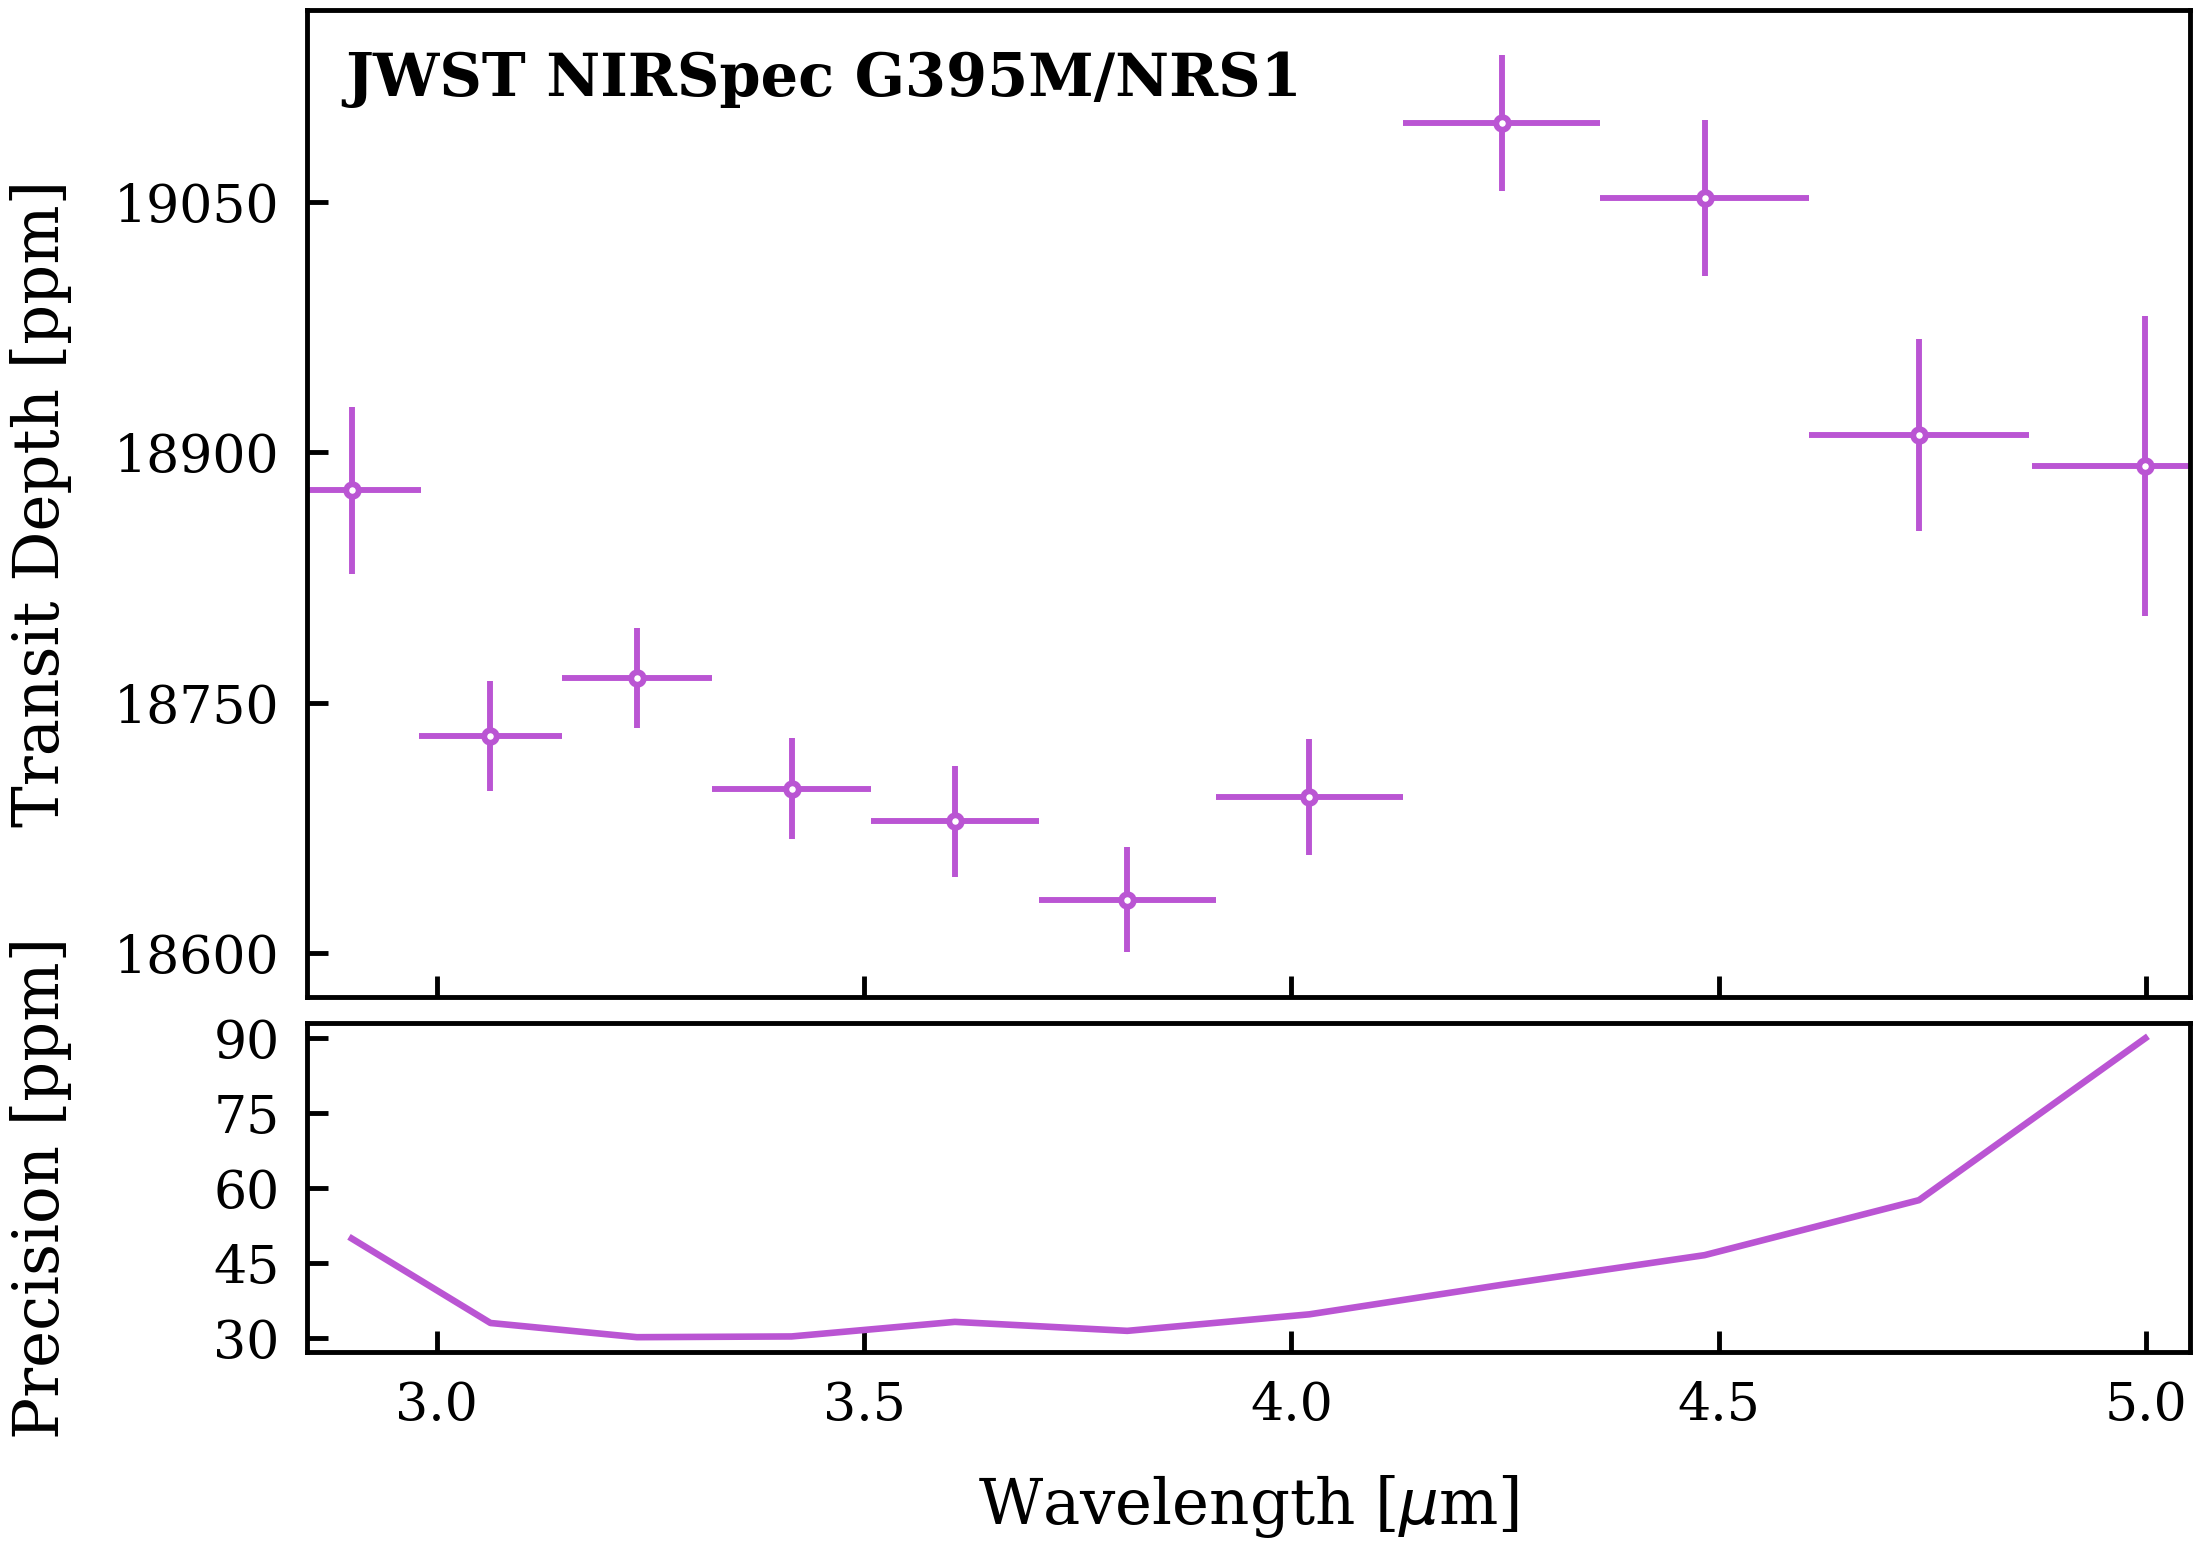

In [6]:
from plotting import plot_spectrum_precision

spectrum_figure = RESULT_ROOT / "notebook_spectrum_publication.png"
if spectrum_figure.exists():
    raise FileExistsError(f"Refusing to overwrite {spectrum_figure}")
plot_spectrum_precision(
    spectrum["wavelength"],
    spectrum["depth_ppm00"],
    spectrum["depth_err_ppm00"],
    spectrum_figure,
    instrument_label="HAT-P-18_NIRSPEC_G395M_nrs1",
    wavelength_err=spectrum["wavelength_err"],
)
display(Image(filename=str(spectrum_figure)))


## What to use next

Use the YAML beside the existing example notebook as the fuller configuration starting point. For scientific inference, restore the intended spectral grid and convergence thresholds, increase warmup/draw counts, and evaluate all diagnostics before using the spectrum.